#  Решение задачи классификации при помощи пакета `torch`.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://lightning.ai/docs/torchmetrics/stable/
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://www.learnpytorch.io/02_pytorch_classification/
* https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler
* https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb45
* https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
* https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b7
* https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss
* https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss52

## Задачи для совместного разбора

In [1]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th

Scalar = TensorType[()]
patch_typeguard()

1\. Обсудите подходы к решению задачи классификации на примере синтетического датасета.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу классификации. Разделите датасет на обучающую и тестовую выборку в соотношении 80% на 20%. В качестве функции потерь используйте реализацию `CrossEntropyLoss` из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. 

Используйте модель, состоящую из двух слоев:
1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 2 нейронами.

Выведите график изменения значения функции потерь в процессе обучения. Выведите на экран значения Accuracy, Precision, Recall и F1 для обучающего и тестового множества. 

Выведите на экран облако точек с цветом, соответствующим предсказаниям модели на всем датасете (и обучающей, и тестовой части). 

- [ ] Проверено на семинаре 


In [52]:
import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import TensorDataset, DataLoader
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import TensorDataset, DataLoader

import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler


In [2]:
from sklearn.datasets import make_circles

th.manual_seed(42)

X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.LongTensor(y)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [4]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Linear(10, 2)
)

criterion = nn.CrossEntropyLoss()
optimizer = th.optim.SGD(model.parameters(), lr=0.1)

In [5]:
n_epochs = 300
epoch_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(epoch_loss)

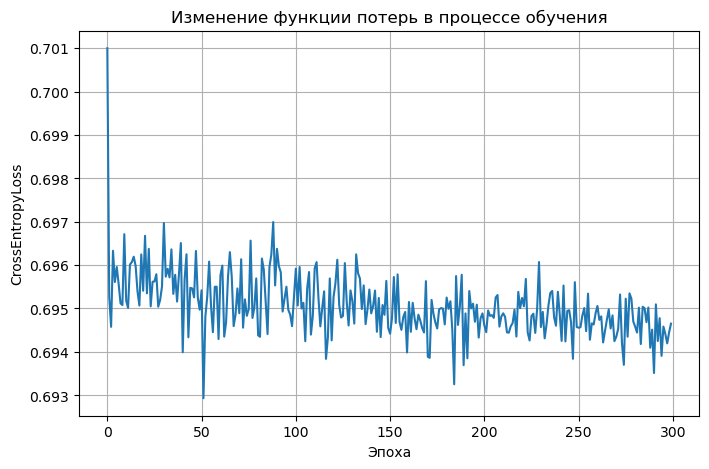

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_losses)
plt.title("Изменение функции потерь в процессе обучения")
plt.xlabel("Эпоха")
plt.ylabel("CrossEntropyLoss")
plt.grid(True)
plt.show()

In [7]:
def get_predictions(model, X):
    model.eval()
    with th.no_grad():
        logits = model(X)
        preds = th.argmax(logits, dim=1)
    return preds

train_preds = get_predictions(model, X_train)
test_preds = get_predictions(model, X_test)
train_accuracy = accuracy_score(y_train.numpy(), train_preds.numpy())
train_precision = precision_score(y_train.numpy(), train_preds.numpy())
train_recall = recall_score(y_train.numpy(), train_preds.numpy())
train_f1 = f1_score(y_train.numpy(), train_preds.numpy())

test_accuracy = accuracy_score(y_test.numpy(), test_preds.numpy())
test_precision = precision_score(y_test.numpy(), test_preds.numpy())
test_recall = recall_score(y_test.numpy(), test_preds.numpy())
test_f1 = f1_score(y_test.numpy(), test_preds.numpy())

print("Метрики на обучающей выборке:")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1       : {train_f1:.4f}")

print("\nМетрики на тестовой выборке:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1       : {test_f1:.4f}")

Метрики на обучающей выборке:
Accuracy : 0.5625
Precision: 0.5334
Recall   : 0.9975
F1       : 0.6951

Метрики на тестовой выборке:
Accuracy : 0.5850
Precision: 0.5464
Recall   : 1.0000
F1       : 0.7067


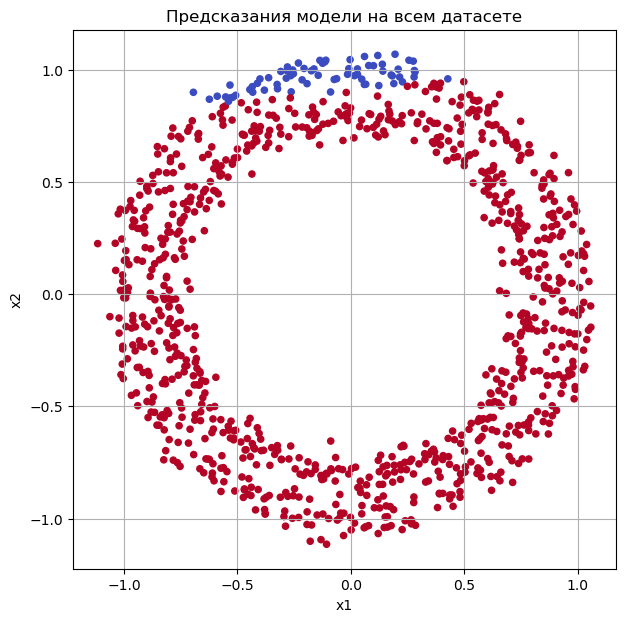

In [8]:
all_preds = get_predictions(model, X)

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    X[:, 0].numpy(),
    X[:, 1].numpy(),
    c=all_preds.numpy(),
    cmap="coolwarm",
    s=20
)
plt.title("Предсказания модели на всем датасете")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

<p class="task" id="2"></p>

2\. Повторите задачу 1, используя другую архитектуру нейронной сети.

1. Полносвязный слой с 10 нейронами;
2. Функция активации ReLU;
3. Полносвязный слой с 2 нейронами.

- [ ] Проверено на семинаре

In [9]:
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.LongTensor(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [11]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 2)
)

criterion = nn.CrossEntropyLoss()
optimizer = th.optim.SGD(model.parameters(), lr=0.1)

In [12]:
n_epochs = 300
epoch_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(epoch_loss)

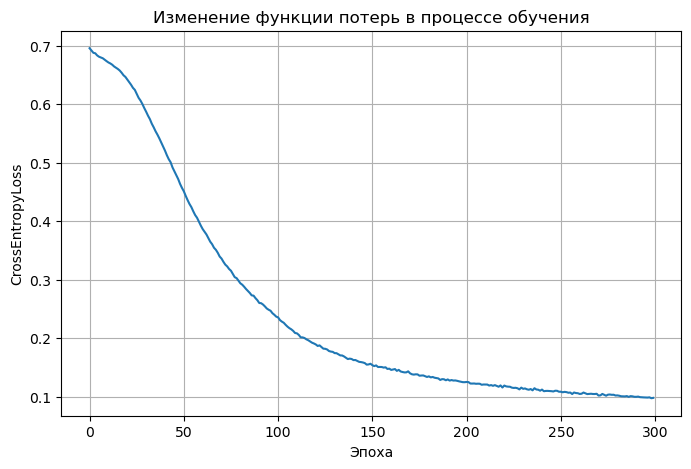

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_losses)
plt.title("Изменение функции потерь в процессе обучения")
plt.xlabel("Эпоха")
plt.ylabel("CrossEntropyLoss")
plt.grid(True)
plt.show()

In [14]:
def get_predictions(model, X):
    model.eval()
    with th.no_grad():
        logits = model(X)
        preds = th.argmax(logits, dim=1)
    return preds

train_preds = get_predictions(model, X_train)
test_preds = get_predictions(model, X_test)

train_accuracy = accuracy_score(y_train.numpy(), train_preds.numpy())
train_precision = precision_score(y_train.numpy(), train_preds.numpy())
train_recall = recall_score(y_train.numpy(), train_preds.numpy())
train_f1 = f1_score(y_train.numpy(), train_preds.numpy())

test_accuracy = accuracy_score(y_test.numpy(), test_preds.numpy())
test_precision = precision_score(y_test.numpy(), test_preds.numpy())
test_recall = recall_score(y_test.numpy(), test_preds.numpy())
test_f1 = f1_score(y_test.numpy(), test_preds.numpy())

print("Метрики на обучающей выборке:")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1       : {train_f1:.4f}")

print("\nМетрики на тестовой выборке:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1       : {test_f1:.4f}")

Метрики на обучающей выборке:
Accuracy : 0.9775
Precision: 0.9848
Recall   : 0.9700
F1       : 0.9773

Метрики на тестовой выборке:
Accuracy : 0.9700
Precision: 0.9608
Recall   : 0.9800
F1       : 0.9703


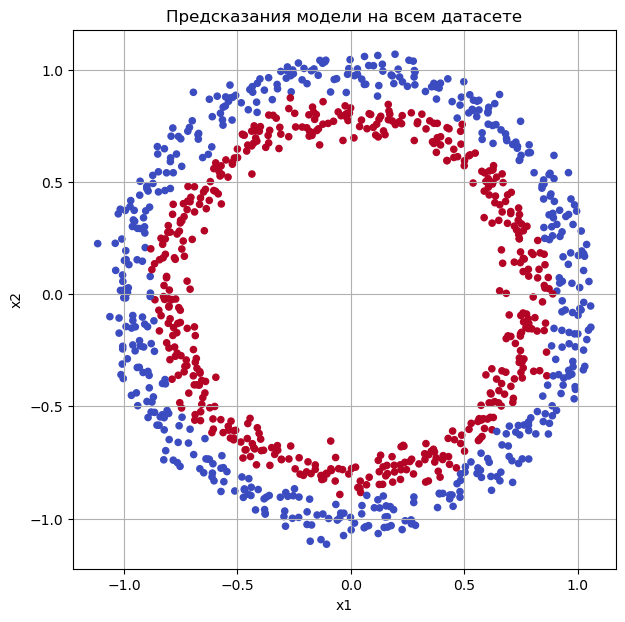

In [15]:
all_preds = get_predictions(model, X)

plt.figure(figsize=(7, 7))
plt.scatter(
    X[:, 0].numpy(),
    X[:, 1].numpy(),
    c=all_preds.numpy(),
    cmap="coolwarm",
    s=20
)
plt.title("Предсказания модели на всем датасете")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

<p class="task" id="3"></p>

3\. `CrossEntropyLoss` может быть использована для задачи классификации на любое количество классов. Для задачи бинарной классификации существуют специфические функции потерь. Решите задачу 2, используя `BCEWithLogitsLoss` в качестве функции потерь.

- [ ] Проверено на семинаре

In [16]:
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)

X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [18]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = th.optim.SGD(model.parameters(), lr=0.1)

In [19]:
n_epochs = 300
epoch_losses = []

for epoch in range(n_epochs):

    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(epoch_loss)

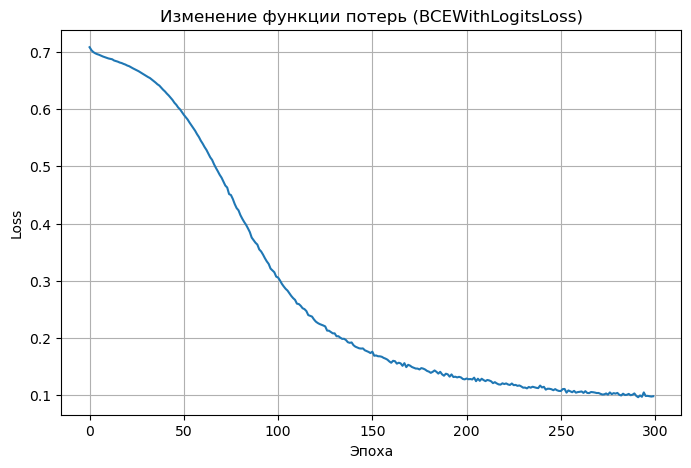

In [20]:
plt.figure(figsize=(8,5))
plt.plot(epoch_losses)
plt.title("Изменение функции потерь (BCEWithLogitsLoss)")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [21]:
def get_predictions(model, X):

    model.eval()
    with th.no_grad():

        logits = model(X)
        probs = th.sigmoid(logits)

        preds = (probs >= 0.5).long()

    return preds

In [22]:
train_preds = get_predictions(model, X_train)
test_preds = get_predictions(model, X_test)

train_accuracy = accuracy_score(y_train.numpy(), train_preds.numpy())
train_precision = precision_score(y_train.numpy(), train_preds.numpy())
train_recall = recall_score(y_train.numpy(), train_preds.numpy())
train_f1 = f1_score(y_train.numpy(), train_preds.numpy())

test_accuracy = accuracy_score(y_test.numpy(), test_preds.numpy())
test_precision = precision_score(y_test.numpy(), test_preds.numpy())
test_recall = recall_score(y_test.numpy(), test_preds.numpy())
test_f1 = f1_score(y_test.numpy(), test_preds.numpy())

print("Метрики на обучающей выборке:")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1       : {train_f1:.4f}")

print("\nМетрики на тестовой выборке:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1       : {test_f1:.4f}")

Метрики на обучающей выборке:
Accuracy : 0.9712
Precision: 0.9748
Recall   : 0.9675
F1       : 0.9711

Метрики на тестовой выборке:
Accuracy : 0.9800
Precision: 0.9800
Recall   : 0.9800
F1       : 0.9800


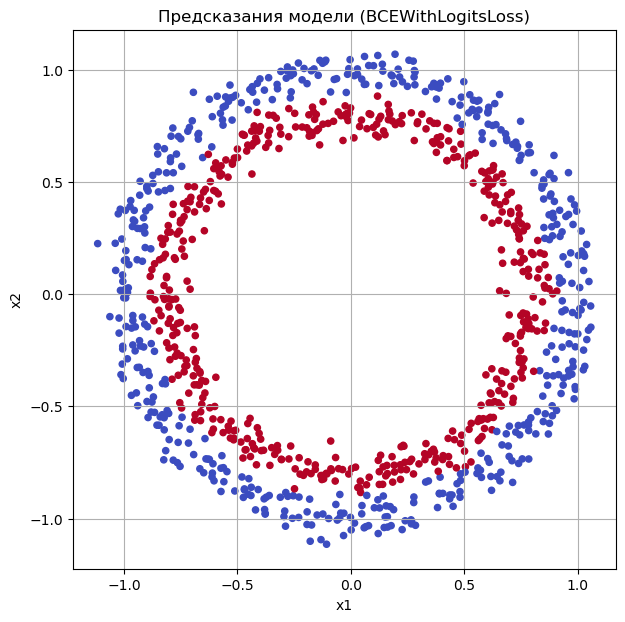

In [23]:
all_preds = get_predictions(model, X)

plt.figure(figsize=(7,7))
plt.scatter(
    X[:,0].numpy(),
    X[:,1].numpy(),
    c=all_preds.numpy(),
    cmap="coolwarm",
    s=20
)
plt.title("Предсказания модели (BCEWithLogitsLoss)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

<p class="task" id="4"></p>

4\. На практике часто задача классификации является несбалансированной. В файлах каталога `imb_task` содержится несбалансированный набор данных. Обучите модель без учета несбалансированности классов (аналогично предыдущим заданиям, можно использовать любую подходящую функцию потерь). Повысьте качество модели (в смысле F1) путем модификации функции потерь (указания специального аргумента, позволяющего учесть несбалансированность классов).

- [ ] Проверено на семинаре

In [34]:
data_dir = Path("imb_task")

X = th.load(data_dir / "imb_X.th")
y = th.load(data_dir / "imb_y.th")

X = X.float()
y = y.float().reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1650, 2])
y shape: torch.Size([1650, 1])


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(),
    y.numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y.numpy()
)

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = th.FloatTensor(X_train)
X_test = th.FloatTensor(X_test)

y_train = th.FloatTensor(y_train).reshape(-1, 1)
y_test = th.FloatTensor(y_test).reshape(-1, 1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [37]:
def build_model(n_features):
    return nn.Sequential(
        nn.Linear(n_features, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

In [38]:
def train_model(model, train_loader, criterion, n_epochs=150, lr=0.05):
    optimizer = th.optim.SGD(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        loss_history.append(sum(batch_losses) / len(batch_losses))

    return loss_history

def get_predictions(model, X):
    model.eval()
    with th.no_grad():
        logits = model(X)
        probs = th.sigmoid(logits)
        preds = (probs >= 0.5).long()
    return preds

def evaluate_model(model, X, y, title=""):
    preds = get_predictions(model, X)

    y_true = y.numpy().ravel().astype(int)
    y_pred = preds.numpy().ravel().astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print()

    return acc, prec, rec, f1


In [39]:
model_plain = build_model(X_train.shape[1])
criterion_plain = nn.BCEWithLogitsLoss()

loss_plain = train_model(
    model=model_plain,
    train_loader=train_loader,
    criterion=criterion_plain,
    n_epochs=150,
    lr=0.05
)

In [40]:
n_pos = (y_train == 1).sum().item()
n_neg = (y_train == 0).sum().item()

pos_weight = th.tensor([n_neg / n_pos], dtype=th.float32)
print(f"pos_weight = {pos_weight.item():.4f}")

model_weighted = build_model(X_train.shape[1])
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

loss_weighted = train_model(
    model=model_weighted,
    train_loader=train_loader,
    criterion=criterion_weighted,
    n_epochs=150,
    lr=0.05
)

pos_weight = 10.0000


In [41]:
print("Без учета несбалансированности:")
plain_metrics = evaluate_model(model_plain, X_test, y_test, title="Тестовая выборка")

print("С учетом несбалансированности классов:")
weighted_metrics = evaluate_model(model_weighted, X_test, y_test, title="Тестовая выборка")

Без учета несбалансированности:
Тестовая выборка
Accuracy : 0.9364
Precision: 0.9091
Recall   : 0.3333
F1       : 0.4878

С учетом несбалансированности классов:
Тестовая выборка
Accuracy : 0.7939
Precision: 0.2935
Recall   : 0.9000
F1       : 0.4426



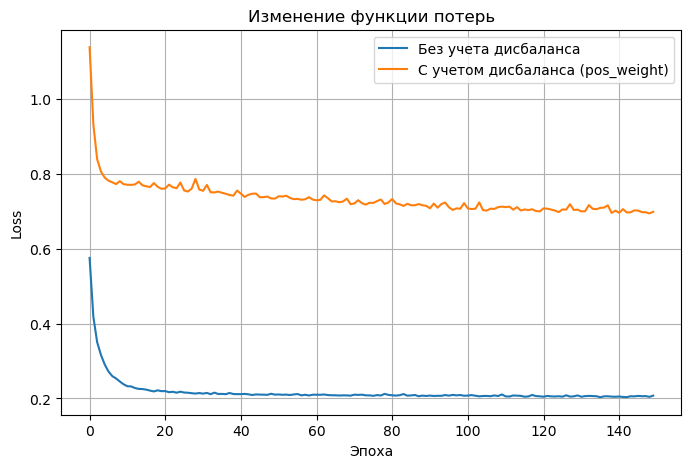

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(loss_plain, label="Без учета дисбаланса")
plt.plot(loss_weighted, label="С учетом дисбаланса (pos_weight)")
plt.title("Изменение функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задачи 4, повысив качество модели за счет использования `WeightedRandomSampler` вместо модификации функции потерь.

- [ ] Проверено на семинаре

In [45]:
data_dir = Path("imb_task")

X = th.load(data_dir / "imb_X.th")
y = th.load(data_dir / "imb_y.th")

X = X.float()
y = y.float().reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1650, 2])
y shape: torch.Size([1650, 1])


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(),
    y.numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y.numpy()
)

In [47]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = th.FloatTensor(X_train)
X_test = th.FloatTensor(X_test)

y_train = th.FloatTensor(y_train).reshape(-1, 1)
y_test = th.FloatTensor(y_test).reshape(-1, 1)

train_dataset = TensorDataset(X_train, y_train)

In [53]:
class_counts = th.bincount(y_train.view(-1).long())
print("Количество объектов по классам в train:", class_counts.tolist())

class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train.view(-1).long()]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_plain = DataLoader(train_dataset, batch_size=64, shuffle=True)
train_loader_balanced = DataLoader(train_dataset, batch_size=64, sampler=sampler)

Количество объектов по классам в train: [1200, 120]


In [54]:
def build_model(n_features):
    return nn.Sequential(
        nn.Linear(n_features, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

In [55]:
def train_model(model, train_loader, criterion, n_epochs=150, lr=0.05):
    optimizer = th.optim.SGD(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        loss_history.append(sum(batch_losses) / len(batch_losses))

    return loss_history

def get_predictions(model, X):
    model.eval()
    with th.no_grad():
        logits = model(X)
        probs = th.sigmoid(logits)
        preds = (probs >= 0.5).long()
    return preds

def evaluate_model(model, X, y, title=""):
    preds = get_predictions(model, X)

    y_true = y.numpy().ravel().astype(int)
    y_pred = preds.numpy().ravel().astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print()

    return acc, prec, rec, f1

In [56]:
criterion = nn.BCEWithLogitsLoss()

model_plain = build_model(X_train.shape[1])
loss_plain = train_model(
    model=model_plain,
    train_loader=train_loader_plain,
    criterion=criterion,
    n_epochs=150,
    lr=0.05
)

In [57]:
model_sampler = build_model(X_train.shape[1])
loss_sampler = train_model(
    model=model_sampler,
    train_loader=train_loader_balanced,
    criterion=criterion,
    n_epochs=150,
    lr=0.05
)

In [58]:
print("Без учета несбалансированности:")
plain_metrics = evaluate_model(model_plain, X_test, y_test, title="Тестовая выборка")

print("С учетом несбалансированности через WeightedRandomSampler:")
sampler_metrics = evaluate_model(model_sampler, X_test, y_test, title="Тестовая выборка")

Без учета несбалансированности:
Тестовая выборка
Accuracy : 0.9394
Precision: 0.8571
Recall   : 0.4000
F1       : 0.5455

С учетом несбалансированности через WeightedRandomSampler:
Тестовая выборка
Accuracy : 0.8152
Precision: 0.3038
Recall   : 0.8000
F1       : 0.4404



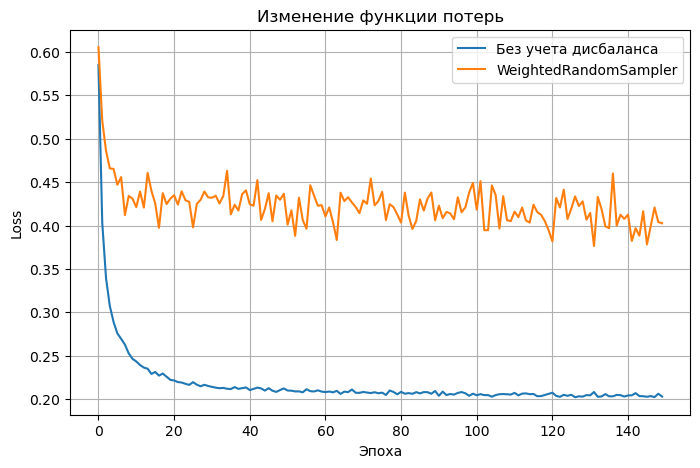

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(loss_plain, label="Без учета дисбаланса")
plt.plot(loss_sampler, label="WeightedRandomSampler")
plt.title("Изменение функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()